## EJERCICIO 1

CÍRCULO (SOM 2D)
Entrenando el SOM Círculo - 1000 épocas...


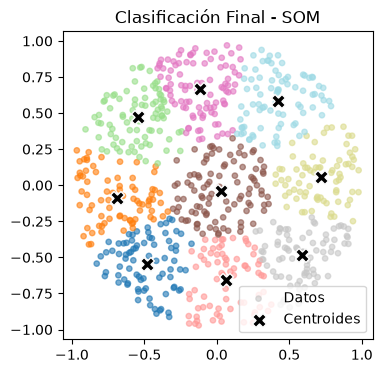

LETRA T (SOM 1D)
Entrenando el SOM Letra T - 1000 épocas...


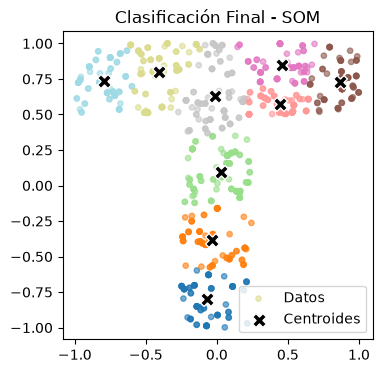

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import csv

class SOM:
    def __init__(self, filas, columnas, dim_entrada, tasa_aprendizaje=0.5, radio_vecindad=None):
        self.filas = filas
        self.columnas = columnas
        self.dim_entrada = dim_entrada
        
        np.random.seed(42)
        self.pesos = np.random.uniform(-0.5, 0.5, (filas, columnas, dim_entrada))
        
        self.ta_inicial = tasa_aprendizaje
        # El radio es la cantidad de casilleros alrededor de la ganadora
        if radio_vecindad is None:
            self.radio_inicial = max(filas, columnas) // 2
        else:
            self.radio_inicial = int(radio_vecindad)

    def encontrar_bmu(self, x):
        """Encuentra la neurona ganadora (distancia Euclidiana)"""
        distancias = np.linalg.norm(self.pesos - x, axis=2)
        bmu_idx = np.unravel_index(np.argmin(distancias, axis=None), distancias.shape)
        return bmu_idx

    def actualizar_pesos(self, x, f_bmu, c_bmu, radio, ta_actual):
        # Definimos los límites del cuadrado asegurando que no se salgan de la matriz
        f_min = max(0, f_bmu - radio)
        f_max = min(self.filas, f_bmu + radio + 1)
        c_min = max(0, c_bmu - radio)
        c_max = min(self.columnas, c_bmu + radio + 1)
        
        # W = W + ta_actual * (x - W) 
        self.pesos[f_min:f_max, c_min:c_max, :] += ta_actual * (x - self.pesos[f_min:f_max, c_min:c_max, :])

    def train(self, datos, epocas_ordenamiento=500, epocas_transicion=300, epocas_ajuste=200):
      
        # ETAPA 0: Ordenamiento Global (tasa aprendizaje alta)
        radio = self.radio_inicial
        ta_actual = self.ta_inicial
        
        for _ in range(epocas_ordenamiento):
            for x in datos:
                f_bmu, c_bmu = self.encontrar_bmu(x)
                self.actualizar_pesos(x, f_bmu, c_bmu, radio, ta_actual)
                

        # ETAPA 1: Transición (Decaimiento lineal)
        radio_final = 1
        ta_final = 0.1
        
        for epoca in range(epocas_transicion):
            np.random.shuffle(datos)
            
            # Cálculo de la pendiente lineal (y = mx + b)
            radio_actual = int(round(radio - ((radio - radio_final) / epocas_transicion) * epoca))
            ta_actual = ta_actual - ((ta_actual - ta_final) / epocas_transicion) * epoca
            
            for x in datos:
                f_bmu, c_bmu = self.encontrar_bmu(x)
                self.actualizar_pesos(x, f_bmu, c_bmu, radio_actual, ta_actual)
                

        # ETAPA 2: Ajusta la ganadora con una tasa baja
        radio_ajuste = 0 
        ta_ajuste = 0.01
        
        for _ in range(epocas_ajuste):
            np.random.shuffle(datos)
            for x in datos:
                f_bmu, c_bmu = self.encontrar_bmu(x)
                self.actualizar_pesos(x, f_bmu, c_bmu, radio_ajuste, ta_ajuste)


    def obtener_bmus(self, datos):
        """Devuelve las neuronas ganadoras"""
        bmus_1d = []
        bmus_2d = []
        for x in datos:
            f, c = self.encontrar_bmu(x)
            bmus_1d.append(f * self.columnas + c)
            bmus_2d.append((f, c))
        return np.array(bmus_1d), bmus_2d


    def graficar_clasificacion_2D(self, datos, dim_x=0, dim_y=1):
        """Graficador de dispersión genérico para cruzar 2 dimensiones"""
        colores = []
        for x in datos:
            f, c = self.encontrar_bmu(x)
            colores.append(f * self.columnas + c)
            
        plt.figure(figsize=(4, 4))
        plt.scatter(datos[:, dim_x], datos[:, dim_y], c=colores, cmap='tab20', s=15, alpha=0.6, label='Datos')
        
        centroides_x = self.pesos[:, :, dim_x].flatten()
        centroides_y = self.pesos[:, :, dim_y].flatten()
        
        plt.scatter(centroides_x, centroides_y, c='black', marker='X', s=100, label='Centroides', edgecolors='white')
        plt.title("Clasificación Final - SOM")
        plt.legend()
        plt.axis('equal')
        plt.show()



def cargar_datos(ruta_archivo):
    datos_x = []
    yd = []
    with open(ruta_archivo, 'r') as archivo:
        archivo_csv = csv.reader(archivo)
        for fila in archivo_csv:
            entradas = [float(val) for val in fila]
            datos_x.append(entradas)
            # no hay y real
            yd.append(0) 
    return np.array(datos_x), np.array(yd)


if __name__ == "__main__":
    
    # CIRCULO (SOM 2D)
    print("CÍRCULO (SOM 2D)")
    datos_circulo, _ = cargar_datos('datos/circulo.csv')
    
    # SOM de 3x3 neuronas (9 neuronas)
    som_circulo = SOM(filas=3, columnas=3, dim_entrada=2, tasa_aprendizaje=0.5)
    print("Entrenando el SOM Círculo - 1000 épocas...")
    som_circulo.train(datos_circulo)
    som_circulo.graficar_clasificacion_2D(datos_circulo)

     
    # 'T' (SOM 1D)
    print("LETRA T (SOM 1D)")
    datos_te, _ = cargar_datos('datos/te.csv')

    # anterior 3x3 = 9 neuronas --> 1x9 = 9
    som_te = SOM(filas=1, columnas=9, dim_entrada=2, tasa_aprendizaje=0.5)
    print("Entrenando el SOM Letra T - 1000 épocas...")
    som_te.train(datos_te)
    som_te.graficar_clasificacion_2D(datos_te)

In [ ]:
def graficar_estado_2D(self, datos, titulo="Estado del SOM"):
    plt.figure(figsize=(6, 6))
    # Graficar los datos de fondo
    plt.scatter(datos[:, 0], datos[:, 1], c='lightgrey', s=10, label='Datos')

    for i in range(self.filas):
        for j in range(self.columnas):
            p_actual = self.pesos[i, j]
            if j < self.columnas - 1:
                p_der = self.pesos[i, j+1]
                plt.plot([p_actual[0], p_der[0]], [p_actual[1], p_der[1]], 'k-', linewidth=1)
            if i < self.filas - 1:
                p_abajo = self.pesos[i+1, j]
                plt.plot([p_actual[0], p_abajo[0]], [p_actual[1], p_abajo[1]], 'k-', linewidth=1)

    # Graficar los nodos encima de las lineas
        plt.scatter(self.pesos[:, :, 0], self.pesos[:, :, 1], c='red', s=30, label='Neuronas', zorder=5)
        plt.title(titulo)
        plt.axis('equal')
        plt.legend()
        plt.show()


som_circulo.graficar_estado_2D(datos_circulo, titulo="Círculo - Estado Inicial") 